# Autoencoders Clean Gaussians

# Imports

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchsummary import summary

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Data

In [2]:
n_per_clust = 1000
img_size = 91
x = np.linspace(-4,4,img_size)
X, Y = np.meshgrid(x, x)

# two widths
widths = np.linspace(2,5,n_per_clust)

# images and labels placeholders
images = torch.zeros(n_per_clust, 1, img_size, img_size)

for i in range(n_per_clust):
  ro = np.random.randn(2) # random offset
  G = np.exp(
      - ((X-ro[0])**2 + (Y-ro[1])**2) /
        (2*widths[i]**2)
  )

  # add noise
  G = G + np.random.randn(img_size, img_size) / 5

  # add image and label
  images[i,:,:,:] = torch.tensor(G).view(1,img_size, img_size)

# Occlusion

In [4]:
# images shape: (N, C, H, W)
margin = 10

for i in range(images.shape[0]):
    img = images[i, 0]  # (H, W)
    H, W = img.shape

    occ_size = np.random.randint(5, 10)

    if np.random.rand() < 0.5:
        # pionowa (kolumny)
        start = np.random.randint(margin, W - occ_size - margin)
        img[:, start:start + occ_size] = 0
    else:
        # pozioma (wiersze)
        start = np.random.randint(margin, H - occ_size - margin)
        img[start:start + occ_size, :] = 0

    images[i, 0] = img


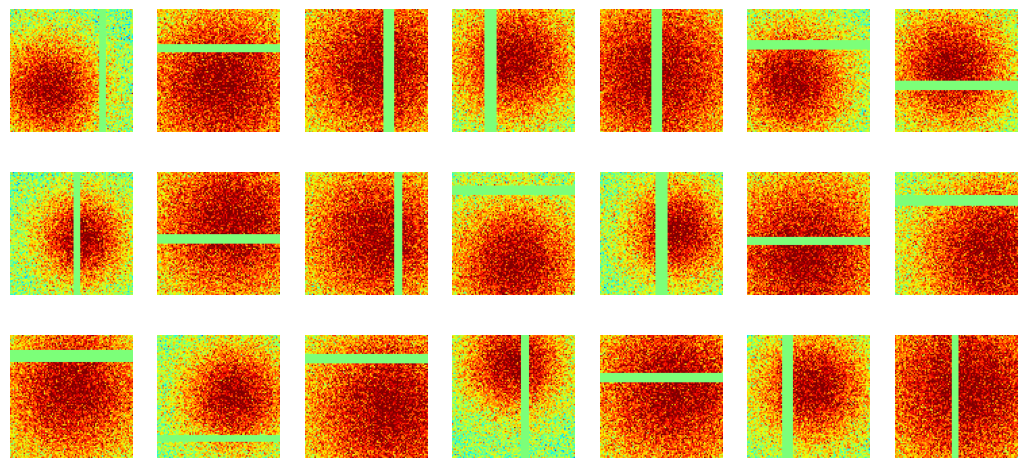

In [5]:
fig, axs = plt.subplots(3, 7, figsize = (13, 6))

for i, ax in enumerate(axs.flatten()):
  rand_row = np.random.randint(images.shape[0])
  ax.imshow(images[rand_row].squeeze(), vmin = -1, vmax = 1, cmap = 'jet')
  ax.axis('off')
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

# Model

In [6]:
def CreateModel():

  class CreateNet(nn.Module):
    def __init__(self):
      super().__init__()

      self.enc = nn.Sequential(
          nn.Conv2d(1, 6, 3, 1, 1),
          nn.ReLU(),
          nn.MaxPool2d(2,2),
          nn.Conv2d(6, 4, 3, 1, 1),
          nn.ReLU(),
          nn.MaxPool2d(2,2),
      )

      self.dec = nn.Sequential(
          nn.ConvTranspose2d(4, 6, 3, 2),
          nn.ReLU(),
          nn.ConvTranspose2d(6, 1, 3, 2)
      )

    def forward(self, x):
      x = self.dec(self.enc(x))
      return x

  net = CreateNet()
  loss_fn = nn.MSELoss()
  optimizer = torch.optim.Adam(net.parameters(), lr = 1e-3)

  return net, loss_fn, optimizer

In [7]:
net, loss_fn, optimizer = CreateModel()
y_hat = net(images[:10,:,:,:])
loss = loss_fn(y_hat, images[:10])
loss

tensor(0.2492, grad_fn=<MseLossBackward0>)

In [10]:
summary(net,(1,img_size, img_size))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 91, 91]              60
              ReLU-2            [-1, 6, 91, 91]               0
         MaxPool2d-3            [-1, 6, 45, 45]               0
            Conv2d-4            [-1, 4, 45, 45]             220
              ReLU-5            [-1, 4, 45, 45]               0
         MaxPool2d-6            [-1, 4, 22, 22]               0
   ConvTranspose2d-7            [-1, 6, 45, 45]             222
              ReLU-8            [-1, 6, 45, 45]               0
   ConvTranspose2d-9            [-1, 1, 91, 91]              55
Total params: 557
Trainable params: 557
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 1.24
Params size (MB): 0.00
Estimated Total Size (MB): 1.27
---------------------------------------------------

# Check Image after 1 Spin

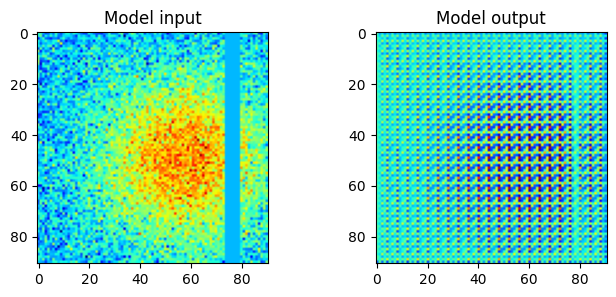

In [8]:
fig, ax = plt.subplots(1,2,figsize = (8,3))
ax[0].imshow(torch.squeeze(images[0,0,:,:]).detach(), cmap = 'jet')
ax[0].set_title('Model input')
ax[1].imshow(torch.squeeze(y_hat[0,0,:,:]).detach(), cmap = 'jet')
ax[1].set_title('Model output')

plt.show()

# Train

In [11]:
def RunModel(epochs):

  # create a new model
  net, loss_fn, optimizer = CreateModel()

  # initialize losses
  losses = torch.zeros(epochs)

  for epoch in range(epochs):

    # pick images
    pics_2_use = np.random.choice(n_per_clust, size = 32, replace = False)
    X = images[pics_2_use,:,:,:]

    # forward pass
    y_hat = net(X)
    loss = loss_fn(y_hat, X)
    losses[epoch] = loss.item()

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch%100==0:
      print(f'Epoch: {epoch} | Loss: {loss:.3f}')

  return losses, net

In [12]:
losses, net = RunModel(epochs = 500)

Epoch: 0 | Loss: 0.337
Epoch: 100 | Loss: 0.133
Epoch: 200 | Loss: 0.051
Epoch: 300 | Loss: 0.045
Epoch: 400 | Loss: 0.044


# Plots

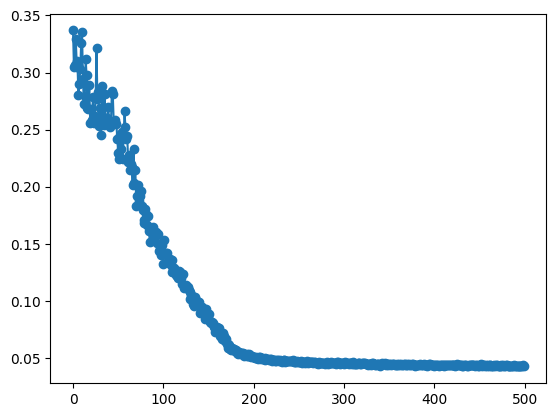

In [13]:
plt.plot(losses, '-o')
plt.show()

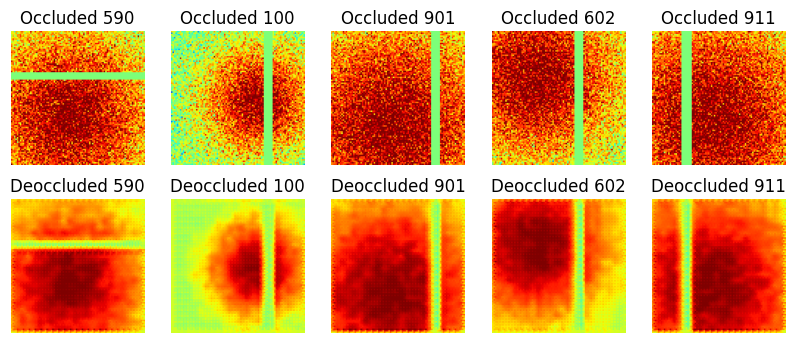

In [14]:
fig, axs = plt.subplots(2, 5, figsize = (10, 4))

rand_rows = np.random.choice(images.shape[0], size = 5)
imgs = images[rand_rows]
deocc_imgs = net(imgs)

for i in range(5):

  axs[0][i].imshow(imgs[i].squeeze(), vmin = -1, vmax = 1, cmap = 'jet')
  axs[0][i].axis('off')
  axs[0][i].set_xticks([])
  axs[0][i].set_yticks([])
  axs[0][i].set_title(f'Occluded {rand_rows[i]}')

  axs[1][i].imshow(deocc_imgs[i].detach().squeeze(), vmin = -1, vmax = 1, cmap = 'jet')
  axs[1][i].axis('off')
  axs[1][i].set_xticks([])
  axs[1][i].set_yticks([])
  axs[1][i].set_title(f'Deoccluded {rand_rows[i]}')

plt.show()

Model doesn't perform well, occlusion is still visible. Let's conduct several experiments to see if we can find the reason behind poor performance or we could improve the model.

# Experiments

## Test Overfitting

We're going to generate fake test dataset based on same principles as train set, and we're going to see if the model overfits.

In [15]:
n_per_clust = 100
img_size = 91
x = np.linspace(-4,4,img_size)
X, Y = np.meshgrid(x, x)

# two widths
widths = np.linspace(2,5,n_per_clust)

# images and labels placeholders
test_images = torch.zeros(n_per_clust, 1, img_size, img_size)

for i in range(n_per_clust):
  ro = np.random.randn(2) # random offset
  G = np.exp(
      - ((X-ro[0])**2 + (Y-ro[1])**2) /
        (2*widths[i]**2)
  )

  # add noise
  G = G + np.random.randn(img_size, img_size) / 5

  # add image and label
  test_images[i,:,:,:] = torch.tensor(G).view(1,img_size, img_size)

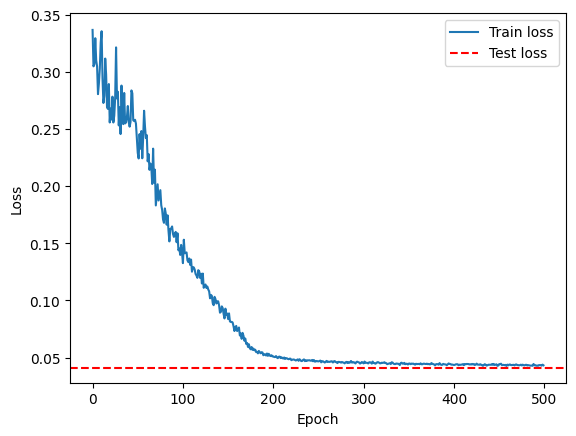

In [16]:
y_test = net(test_images)
test_loss = loss_fn(y_test, test_images)

avg_train_loss = torch.mean(losses[-50:])

plt.plot(losses.numpy(), label='Train loss')
plt.axhline(test_loss.item(), color='r', linestyle='--', label='Test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Train Loss and Test Loss are similar, i.e. we don't have overfitting.

## Check AvgPool

In [17]:
def CreateModel():

  print('Testing AvgPool')

  class CreateNet(nn.Module):
    def __init__(self):
      super().__init__()

      self.enc = nn.Sequential(
          nn.Conv2d(1, 6, 3, 1, 1),
          nn.ReLU(),
          nn.AvgPool2d(2,2),
          nn.Conv2d(6, 4, 3, 1, 1),
          nn.ReLU(),
          nn.AvgPool2d(2,2),
      )

      self.dec = nn.Sequential(
          nn.ConvTranspose2d(4, 6, 3, 2),
          nn.ReLU(),
          nn.ConvTranspose2d(6, 1, 3, 2)
      )

    def forward(self, x):
      x = self.dec(self.enc(x))
      return x

  net = CreateNet()
  loss_fn = nn.MSELoss()
  optimizer = torch.optim.Adam(net.parameters(), lr = 1e-3)

  return net, loss_fn, optimizer

In [19]:
losses_avgPool, net_avgPool = RunModel(epochs = 500)

Testing AvgPool
Epoch: 0 | Loss: 0.123
Epoch: 100 | Loss: 0.056
Epoch: 200 | Loss: 0.043
Epoch: 300 | Loss: 0.039
Epoch: 400 | Loss: 0.039


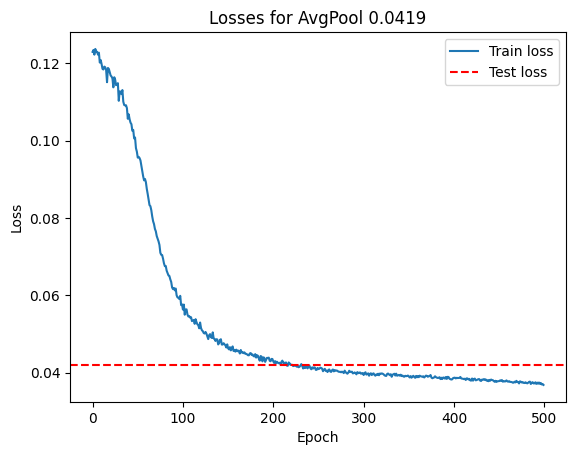

In [22]:
y_test_avgPool = net_avgPool(test_images)
test_loss_avgPool = loss_fn(y_test_avgPool, test_images)

avg_train_loss = torch.mean(losses[-50:])

plt.plot(losses_avgPool.numpy(), label='Train loss')
plt.axhline(test_loss_avgPool.item(), color='r', linestyle='--', label='Test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Losses for AvgPool {test_loss_avgPool:.4f}')
plt.legend()
plt.show()

AvgPooling shows slight overfitting but achieves lower overall loss than MaxPool.

## Nonlinearity on last layer

The final output doesn't have a nonlinearity (e.g., relu, sigmoid, tanh). Does it need one? Would that help? What
are some arguments for and against having a nonlinear activation function on the output of the decover? Try adding
one and see if it improves (via the final loss and visual inspection) the result. Let's stick to AvgPool due to better results.

In [23]:
def CreateModel():

  print('Testing Sigmoid')

  class CreateNet(nn.Module):
    def __init__(self):
      super().__init__()

      self.enc = nn.Sequential(
          nn.Conv2d(1, 6, 3, 1, 1),
          nn.ReLU(),
          nn.AvgPool2d(2,2),
          nn.Conv2d(6, 4, 3, 1, 1),
          nn.ReLU(),
          nn.AvgPool2d(2,2),
      )

      self.dec = nn.Sequential(
          nn.ConvTranspose2d(4, 6, 3, 2),
          nn.ReLU(),
          nn.ConvTranspose2d(6, 1, 3, 2),
          nn.Sigmoid() # test
      )

    def forward(self, x):
      x = self.dec(self.enc(x))
      return x

  net = CreateNet()
  loss_fn = nn.MSELoss()
  optimizer = torch.optim.Adam(net.parameters(), lr = 1e-3)

  return net, loss_fn, optimizer

In [25]:
losses_sigmoid, net_sigmoid = RunModel(epochs = 500)

Testing Sigmoid
Epoch: 0 | Loss: 0.130
Epoch: 100 | Loss: 0.123
Epoch: 200 | Loss: 0.077
Epoch: 300 | Loss: 0.062
Epoch: 400 | Loss: 0.054


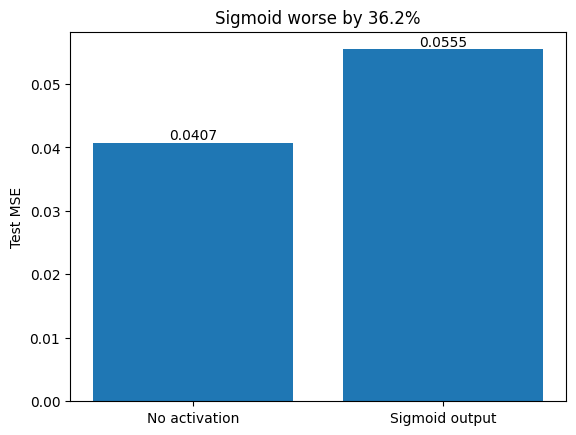

In [26]:
y_test_sigmoid = net_sigmoid(test_images)
test_loss_sigmoid = loss_fn(y_test_sigmoid, test_images)
test_loss_sigmoid.item()

vals = [
    test_loss.item(),
    test_loss_sigmoid.item()
]

labels = ['No activation', 'Sigmoid output']

pct = (vals[1] - vals[0]) / vals[0] * 100

plt.bar(labels, vals)
plt.ylabel('Test MSE')
plt.title(f'Sigmoid worse by {pct:.1f}%')

for i, v in enumerate(vals):
    plt.text(i, v, f'{v:.4f}', ha='center', va='bottom')

plt.show()

Loss is slightly worse with adding Sigmoid at the output layer.

## BCELoss instead of MSELoss

BCEloss can be used when the data are between 0 and 1. Normalize the images so they are appropriately scaled, and then use BCEloss instead of MSEloss. We're going to leave AvgPool and drop Sigmoid at the output layer.

In [27]:
norm_images = images / torch.max(images)
norm_test_images = test_images / torch.max(test_images)

In [28]:
def CreateModel():

  print('Testing BCELoss')

  class CreateNet(nn.Module):
    def __init__(self):
      super().__init__()

      self.enc = nn.Sequential(
          nn.Conv2d(1, 6, 3, 1, 1),
          nn.ReLU(),
          nn.AvgPool2d(2,2),
          nn.Conv2d(6, 4, 3, 1, 1),
          nn.ReLU(),
          nn.AvgPool2d(2,2),
      )

      self.dec = nn.Sequential(
          nn.ConvTranspose2d(4, 6, 3, 2),
          nn.ReLU(),
          nn.ConvTranspose2d(6, 1, 3, 2)
      )

    def forward(self, x):
      x = self.dec(self.enc(x))
      return x

  net = CreateNet()
  loss_fn = nn.BCEWithLogitsLoss()
  optimizer = torch.optim.Adam(net.parameters(), lr = 1e-3)

  return net, loss_fn, optimizer

In [29]:
def RunModel(epochs):

  # create a new model
  net, loss_fn, optimizer = CreateModel()

  # initialize losses
  losses = torch.zeros(epochs)

  for epoch in range(epochs):

    # pick images
    pics_2_use = np.random.choice(n_per_clust, size = 32, replace = False)
    X = norm_images[pics_2_use,:,:,:]

    # forward pass
    y_hat = net(X)
    loss = loss_fn(y_hat, X)
    losses[epoch] = loss.item()

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch%100==0:
      print(f'Epoch: {epoch} | Loss: {loss:.3f}')

  return losses, net

In [31]:
losses_bceLoss, net_bceLoss = RunModel(epochs = 500)

Testing BCELoss
Epoch: 0 | Loss: 0.700
Epoch: 100 | Loss: 0.529
Epoch: 200 | Loss: 0.411
Epoch: 300 | Loss: 0.398
Epoch: 400 | Loss: 0.391


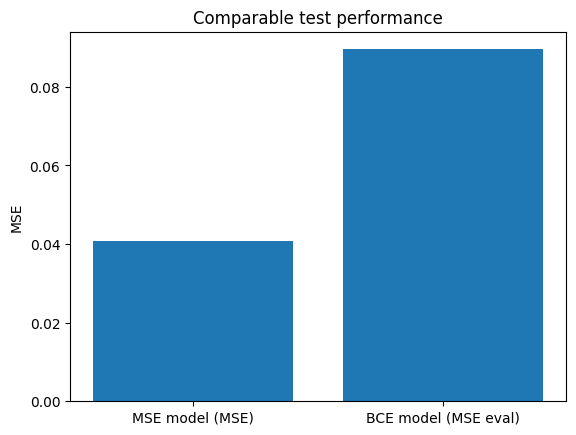

In [32]:
y_hat_bceLoss = net(norm_test_images)
test_loss_bceLoss = loss_fn(y_hat_bceLoss, norm_test_images)

# MSE already computed
mse_mse = test_loss.item()

# compute comparable MSE for BCE-trained model
mse_bce = torch.mean(
    (torch.sigmoid(y_hat_bceLoss) - norm_test_images) ** 2
).item()

vals = [mse_mse, mse_bce]
labels = ['MSE model (MSE)', 'BCE model (MSE eval)']

plt.bar(labels, vals)
plt.ylabel('MSE')
plt.title('Comparable test performance')
plt.show()

MSE Loss still performs better.